In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [3]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [4]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

In [5]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 13.523975372314453


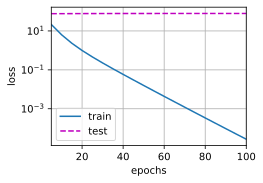

In [6]:
train(lambd=0)

w的L2范数是： 0.40654638409614563


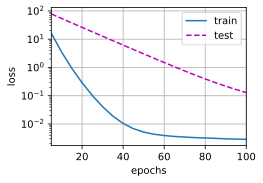

In [7]:
train(lambd=3)

# 权重衰减（L2正则化）总结

核心：权重衰减、L2正则化、过拟合缓解

---

## 一、核心定位

1. **解决问题**：缓解模型**过拟合**，当无法通过扩充训练数据改善时的核心正则化手段

2. **核心思想**：通过限制权重向量的大小降低模型复杂度，认为“权重更接近0的模型更简单、泛化能力更强”

3. **别名**：L2正则化，线性模型中使用该方法称为**岭回归**

---

## 二、数学原理

### 1. 损失函数的调整

以线性回归为例，原始损失仅关注预测误差：

 $L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \frac{1}{2}(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)})^2$ 

加入L2范数惩罚项后的正则化损失：

 $L_{reg}(\mathbf{w}, b) = L(\mathbf{w}, b) + \frac{\lambda}{2}\|\mathbf{w}\|_2^2$ 

-  $\lambda$ ：**正则化系数**（非负超参数）

    -  $\lambda=0$ ：无正则化，等价于原始损失

    -  $\lambda$ 越大：对权重的惩罚越强，模型复杂度越低

- 除以2的目的：求导后抵消平方项系数，简化权重更新公式

### 2. 权重更新规则（小批量SGD）

 $\mathbf{w} \leftarrow (1 - \eta\lambda)\mathbf{w} - \eta \frac{1}{|\mathcal{B}|}\sum_{i \in \mathcal{B}} \mathbf{x}^{(i)}(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)})$ 

- 关键变化：权重先乘以衰减因子  $(1-\eta\lambda)$ ，实现**每步权重缩小**

-  $\eta$ ：学习率， $|\mathcal{B}|$ ：小批量样本数量

### 3. 关键细节

- **偏置项处理**：通常不对偏置  $b$  施加惩罚（尤其是输出层），仅正则化权重  $\mathbf{w}$ 

- **L2范数优势**：对权重的大分量施加强惩罚，使权重均匀分布在多特征上，提升模型稳定性

- **与L1正则化的区别**

|正则化方式|核心特点|应用场景|
|---|---|---|
|L2（权重衰减）|权重连续缩小，无稀疏性|通用正则化，避免过拟合|
|L1（套索回归）|权重稀疏化为0，实现特征选择|需筛选关键特征的场景|
---

## 三、实验验证（高维线性回归）

### 1. 实验设置

- 输入维度  $d=200$ （高维易过拟合），训练集20样本，测试集100样本

- 标签生成： $y=0.05+\sum_{i=1}^{200}0.01x_i + \epsilon$ ， $\epsilon \sim \mathcal{N}(0,0.01^2)$ 

### 2. 实验结论

|实验配置|训练/测试损失表现|权重L2范数|
|---|---|---|
| $\lambda=0$ （无衰减）|训练损失下降，测试损失上升（严重过拟合）|极大（~14）|
| $\lambda=3$ （有衰减）|训练损失略升，测试损失下降（缓解过拟合）|显著缩小（~0.35）|
---

## 四、两种实现方式（PyTorch）

### 1. 从零实现

```Python

import torch
from d2l import torch as d2l

# 初始化参数
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

# 定义L2惩罚项
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

# 训练函数
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数:', torch.norm(w).item())
```

### 2. 框架简洁实现（推荐）

```Python

import torch
from torch import nn
from d2l import torch as d2l

def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    # 参数初始化
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 优化器配置：仅权重衰减，偏置不衰减
    trainer = torch.optim.SGD([
        {"params": net[0].weight, "weight_decay": wd},
        {"params": net[0].bias}
    ], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数:', net[0].weight.norm().item())
```

---

## 五、核心小结

1. 权重衰减是**L2正则化**的别称，通过在损失中加入权重的L2范数惩罚项限制模型复杂度

2. 权重更新时会乘以衰减因子，实现权重的逐步缩小，避免因权重过大导致的过拟合

3. 正则化系数  $\lambda$  需通过验证集调优，平衡训练误差与泛化能力

4. 深度学习框架中可通过优化器的 `weight_decay` 参数直接配置，无需手动实现惩罚项

5. 通常仅对权重施加衰减，偏置项一般不参与正则化